# Project 3: Unsupervised Learning - Customer Segmentation

This project applies unsupervised learning techniques to retail data
to discover hidden customer groups.

The project uses:
- Data preprocessing
- One-hot encoding
- Feature scaling
- Principal Component Analysis (PCA)
- K-Means clustering
- Elbow Method
- Silhouette Score
- Customer persona analysis

## Cell 1: Import Libraries

This cell imports the Python libraries required for the customer segmentation project.

- Pandas is used for data loading and manipulation.
- NumPy is used for numerical operations.
- Matplotlib and Seaborn are used for visualization.
- StandardScaler is used to standardize numerical features.
- PCA is used for dimensionality reduction.
- KMeans is used for customer clustering.
- Silhouette Score is used to evaluate clustering quality.

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

os.environ["OMP_NUM_THREADS"] = "1"
warnings.filterwarnings("ignore")

print("Warnings suppressed successfully!")
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

print("Libraries imported successfully!")

Warnings suppressed successfully!
Libraries imported successfully!


## Cell 2: Load Dataset

The retail dataset is loaded using Pandas.

The shape of the dataset is displayed to determine the number of rows and columns, and the first few records are displayed to understand the structure of the data.

In [8]:

df = pd.read_csv("Dataset for Data Analytics - Sheet1 (1).csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (1200, 14)


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


## Cell 3: Dataset Understanding

This cell examines the structure of the dataset.

It displays:

- Number of rows
- Number of columns
- Column names
- Data types
- Missing-value counts

This step helps identify which variables can be used for clustering.

In [9]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Number of rows: 1200
Number of columns: 14

Column names:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

Data types:
OrderID                str
Date                   str
CustomerID             str
Product                str
Quantity             int64
UnitPrice          float64
ShippingAddress        str
PaymentMethod          str
OrderStatus            str
TrackingNumber         str
ItemsInCart          int64
CouponCode             str
ReferralSource         str
TotalPrice         float64
dtype: object

Missing values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           

## Cell 4: Data Cleaning

A copy of the original dataset is created.

Duplicate records are removed and rows containing missing values are removed so that the clustering algorithm receives clean data.

The original and cleaned dataset sizes are displayed for comparison.

In [10]:
df_clean = df.copy()

# Remove duplicate records
df_clean = df_clean.drop_duplicates()

# Remove rows containing missing values
df_clean = df_clean.dropna()

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (1200, 14)
Cleaned shape: (891, 14)


## Cell 5: Identify Numerical Features

K-Means clustering works with numerical values.

This cell automatically identifies the numerical columns available in the dataset instead of manually assuming column names.

In [11]:
numeric_columns = df_clean.select_dtypes(include=np.number).columns.tolist()

print("Numerical columns:")
print(numeric_columns)

Numerical columns:
['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']


## Cell 6: Create Customer-Level Dataset

Because the project focuses on customer segmentation, the transaction-level data is converted into customer-level information.

The following customer behaviour features are created:

- Total Spending
- Average Order Value
- Total Quantity Purchased
- Average Unit Price
- Total Items in Cart
- Number of Orders

Each row now represents one customer rather than one transaction.

In [12]:
customer_df = df_clean.groupby("CustomerID").agg(
    Total_Spending=("TotalPrice", "sum"),
    Average_Order_Value=("TotalPrice", "mean"),
    Total_Quantity=("Quantity", "sum"),
    Average_Unit_Price=("UnitPrice", "mean"),
    Total_Items_In_Cart=("ItemsInCart", "sum"),
    Number_of_Orders=("OrderID", "nunique")
).reset_index()

print("Customer-level dataset shape:", customer_df.shape)

display(customer_df.head())

Customer-level dataset shape: (886, 7)


,CustomerID,Total_Spending,Average_Order_Value,Total_Quantity,Average_Unit_Price,Total_Items_In_Cart,Number_of_Orders
0,C10002,1470.03,1470.03,3,490.01,4,1
1,C10054,153.48,153.48,2,76.74,7,1
2,C10126,1349.80,1349.80,2,674.90,4,1
3,C10154,1303.04,1303.04,4,325.76,8,1
4,C10211,635.90,635.90,5,127.18,10,1


## Cell 7: Customer Data Statistics

This cell checks the newly created customer-level dataset for missing values and displays statistical summaries such as mean, minimum, maximum and standard deviation.

In [14]:
print("Missing values:")
print(customer_df.isnull().sum())

print("\nCustomer dataset statistics:")
display(customer_df.describe())

Missing values:
CustomerID             0
Total_Spending         0
Average_Order_Value    0
Total_Quantity         0
Average_Unit_Price     0
Total_Items_In_Cart    0
Number_of_Orders       0
dtype: int64

Customer dataset statistics:


,Total_Spending,Average_Order_Value,Total_Quantity,Average_Unit_Price,Total_Items_In_Cart,Number_of_Orders
count,886.000000,886.000000,886.000000,886.000000,886.000000,886.000000
mean,1063.612359,1060.360835,2.927765,361.268476,5.489842,1.005643
std,823.223347,821.781145,1.416360,196.508542,2.304848,0.074952
min,11.390000,11.390000,1.000000,11.390000,1.000000,1.000000
25%,419.975000,418.352500,2.000000,190.242500,4.000000,1.000000
50%,824.265000,823.065000,3.000000,371.760000,5.000000,1.000000
75%,1592.475000,1582.777500,4.000000,527.542500,7.000000,1.000000
max,3456.400000,3456.400000,6.000000,699.930000,14.000000,2.000000


## Cell 8: Feature Selection

Six customer behaviour features are selected for clustering.

These variables describe purchasing behaviour and allow K-Means to group customers according to similarities in their shopping patterns.

In [15]:
features = [
    "Total_Spending",
    "Average_Order_Value",
    "Total_Quantity",
    "Average_Unit_Price",
    "Total_Items_In_Cart",
    "Number_of_Orders"
]

X = customer_df[features]

print("Features selected for clustering:")
print(features)

Features selected for clustering:
['Total_Spending', 'Average_Order_Value', 'Total_Quantity', 'Average_Unit_Price', 'Total_Items_In_Cart', 'Number_of_Orders']


## Cell 9: Feature Standardization

The selected features have different scales.

For example, total spending can be much larger numerically than the number of orders.

StandardScaler converts the features to a comparable scale so that large numerical values do not dominate the K-Means distance calculations.

In [16]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature standardization completed!")
print("Scaled data shape:", X_scaled.shape)

Feature standardization completed!
Scaled data shape: (886, 6)


## Cell 10: Principal Component Analysis

PCA is applied to reduce the standardized customer features to two dimensions.

This satisfies the Project 3 requirement of using dimensionality reduction before visualizing the customer segments.

The explained variance ratio shows how much information is retained by the two principal components.

In [17]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA completed!")
print("PCA shape:", X_pca.shape)

print("Explained variance ratio:")
print(pca.explained_variance_ratio_)

print("Total explained variance:",
      pca.explained_variance_ratio_.sum())

PCA completed!
PCA shape: (886, 2)
Explained variance ratio:
[0.53104837 0.23122487]
Total explained variance: 0.7622732400477743


## Cell 11: PCA Visualization

The two principal components are plotted to visualize the customer data in two dimensions.

At this stage the customers are not yet assigned to K-Means clusters.

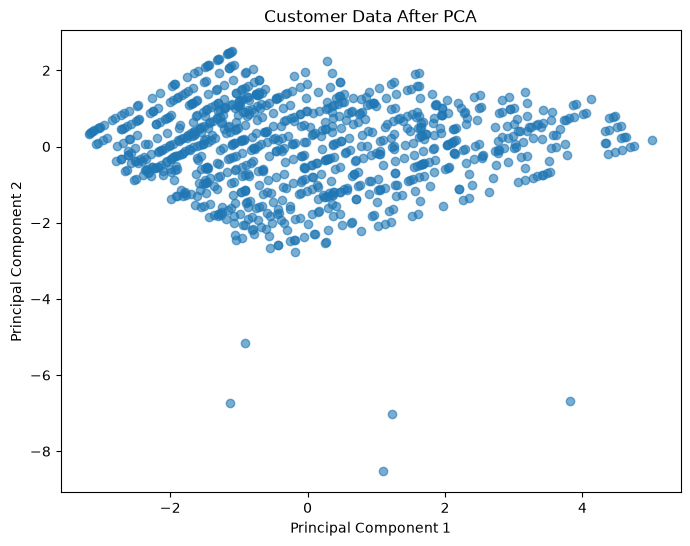

In [18]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Data After PCA")

plt.show()

plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    alpha=0.6
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Data After PCA")

plt.show()

## Cell 12: Elbow Method

The Elbow Method is used to estimate the appropriate number of K-Means clusters.

K-Means models are trained using different values of K from 2 to 10.

The inertia value is recorded for each K.

The resulting graph helps identify the point where increasing the number of clusters provides diminishing improvement.

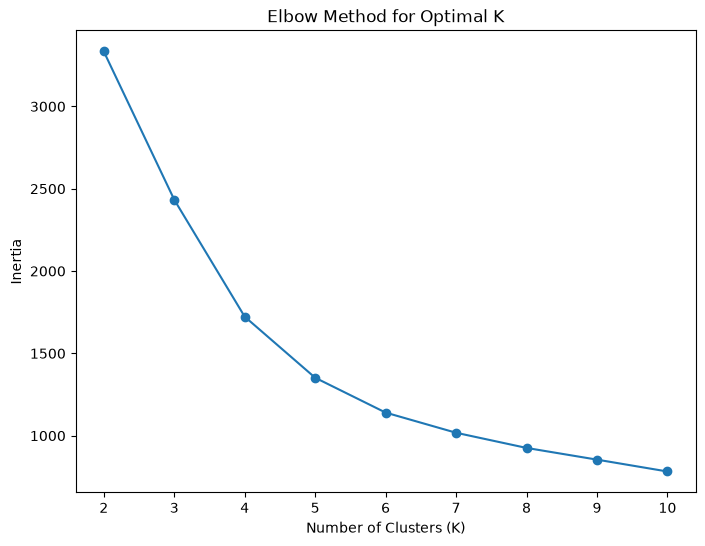

In [21]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))

plt.plot(K_range, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

## Cell 13: Silhouette Score

The Silhouette Score evaluates how well customers fit within their assigned clusters.

The score is calculated for K values from 2 to 10.

The K value producing the highest Silhouette Score is selected as the mathematically preferred number of clusters.

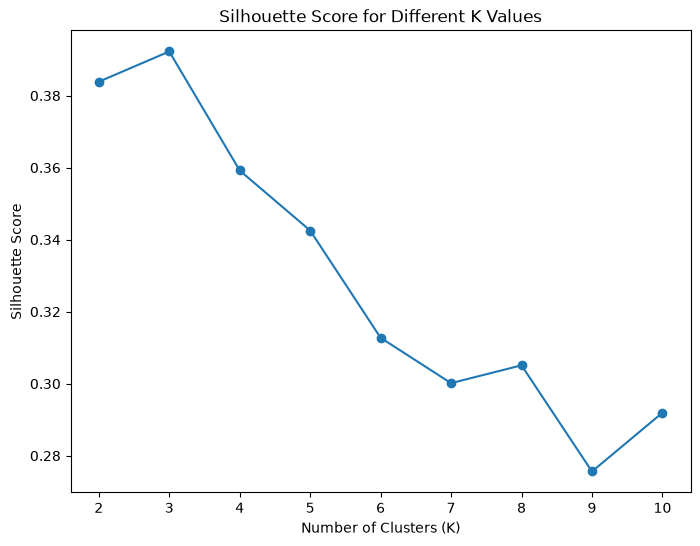

Best K according to Silhouette Score: 3
Best Silhouette Score: 0.39225678589230184


In [23]:
silhouette_scores = []

for k in K_range:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_scaled)
    
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 6))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.show()

best_k = K_range[np.argmax(silhouette_scores)]

print("Best K according to Silhouette Score:", best_k)
print("Best Silhouette Score:", max(silhouette_scores))

## Cell 14: Final K-Means Clustering

The optimal number of clusters obtained from the Silhouette Score is used to train the final K-Means model.

Each customer is assigned to a cluster.

The number of customers in each cluster is displayed.

In [24]:
final_kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

customer_df["Cluster"] = final_kmeans.fit_predict(X_scaled)

print("Final K-Means clustering completed!")

print("\nCluster counts:")
print(customer_df["Cluster"].value_counts().sort_index())

Final K-Means clustering completed!

Cluster counts:
Cluster
0    572
1    309
2      5
Name: count, dtype: int64


## Cell 15: Customer Cluster Visualization

The final K-Means clusters are visualized using two PCA components.

Each point represents a customer, while the different colors represent the assigned clusters.

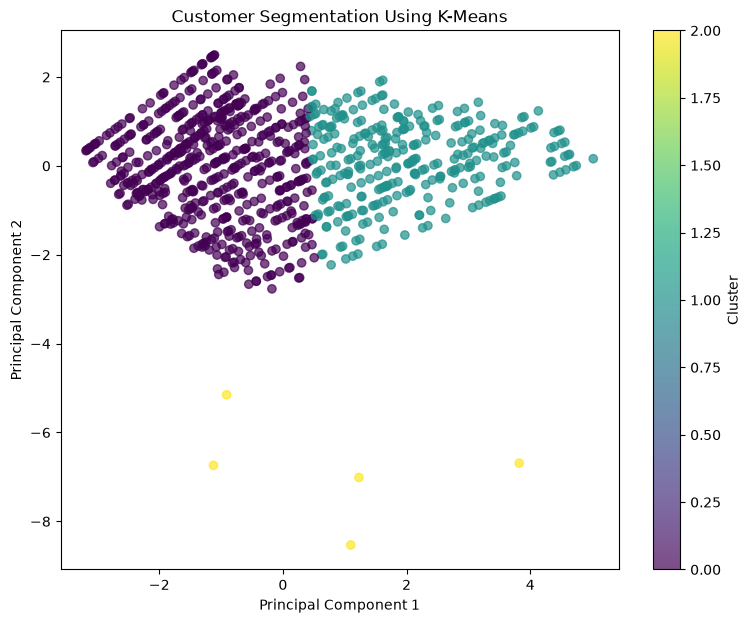

In [25]:
cluster_pca = PCA(n_components=2)

X_cluster_pca = cluster_pca.fit_transform(X_scaled)

plt.figure(figsize=(9, 7))

scatter = plt.scatter(
    X_cluster_pca[:, 0],
    X_cluster_pca[:, 1],
    c=customer_df["Cluster"],
    alpha=0.7
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation Using K-Means")

plt.colorbar(scatter, label="Cluster")

plt.show()

## Cell 16: Cluster Analysis

The average customer behaviour within each cluster is calculated.

This allows us to understand how the clusters differ in terms of spending, order frequency, quantity purchased and other purchasing behaviours.

In [26]:
cluster_summary = customer_df.groupby("Cluster")[features].mean()

display(cluster_summary)

,Total_Spending,Average_Order_Value,Total_Quantity,Average_Unit_Price,Total_Items_In_Cart,Number_of_Orders
Cluster,,,,,,
0,554.906101,554.906101,2.311189,283.833706,4.734266,1.0
1,2003.859417,2003.859417,4.045307,506.547184,6.818770,1.0
2,1152.340000,576.170000,4.400000,241.582000,9.800000,2.0


## Cell 17: Customer Persona Analysis

The characteristics of each cluster are displayed to support business interpretation.

The clusters can be interpreted as customer personas based on their spending, order frequency and purchasing behaviour.

The persona names should be assigned after examining the actual cluster statistics rather than being arbitrarily assigned.

In [27]:
persona_summary = customer_df.groupby("Cluster")[features].mean()

print("Customer Persona Analysis")
print("=" * 60)

for cluster in persona_summary.index:
    
    row = persona_summary.loc[cluster]
    
    print(f"\nCluster {cluster}")
    
    print(f"Average Spending: {row['Total_Spending']:.2f}")
    print(f"Average Order Value: {row['Average_Order_Value']:.2f}")
    print(f"Average Quantity Purchased: {row['Total_Quantity']:.2f}")
    print(f"Average Unit Price: {row['Average_Unit_Price']:.2f}")
    print(f"Average Items in Cart: {row['Total_Items_In_Cart']:.2f}")
    print(f"Average Number of Orders: {row['Number_of_Orders']:.2f}")

Customer Persona Analysis

Cluster 0
Average Spending: 554.91
Average Order Value: 554.91
Average Quantity Purchased: 2.31
Average Unit Price: 283.83
Average Items in Cart: 4.73
Average Number of Orders: 1.00

Cluster 1
Average Spending: 2003.86
Average Order Value: 2003.86
Average Quantity Purchased: 4.05
Average Unit Price: 506.55
Average Items in Cart: 6.82
Average Number of Orders: 1.00

Cluster 2
Average Spending: 1152.34
Average Order Value: 576.17
Average Quantity Purchased: 4.40
Average Unit Price: 241.58
Average Items in Cart: 9.80
Average Number of Orders: 2.00


## Cell 18: Export Results

The final customer segmentation results and cluster summary are exported as CSV files.

These files can be used for further analysis, reporting or submission.

In [28]:
customer_df.to_csv(
    "customer_segmentation_results.csv",
    index=False
)

cluster_summary.to_csv(
    "customer_cluster_summary.csv"
)

print("Results saved successfully!")

Results saved successfully!
